# Gaia orbit: faint companion or hidden twin?
**Question:** a Gaia astrometric orbit says "brown dwarf". Could it be a near-equal-mass star instead?

Allow **7 minutes**. We take two Gaia DR3 astrometric substellar candidates with
radial-velocity follow-up, solve each photocentre orbit for every companion that
fits it, and let the observed XP + 2MASS SED choose between the solutions.

Gaia DR3 **1916454200349735680** turned out to be a near-equal-mass binary;
**LP 769-9** (Gaia DR3 5148853253106611200) hosts a confirmed substellar companion.
Default execution uses the included public-data snapshots; nothing is downloaded.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = Path(globals().get('__file__', Path.cwd())).resolve()
if ROOT.is_file():
    ROOT = ROOT.parent
while not (ROOT / 'src' / 'sedkit').is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / 'src' / 'sedkit').is_dir():
    raise RuntimeError('Open this notebook from the sedkit checkout.')
sys.path.insert(0, str(ROOT / 'src'))
from sedkit import SED, StellarModel
from sedkit.orbit import Q_GRID, amrf, amrf_observed, locus, rank_roots, solve_orbit
from sedkit.plot import BINARY, INK, INK2, PAPER_STYLE, SINGLE

OUT = ROOT / 'examples' / 'group_meeting' / 'outputs'
OUT.mkdir(parents=True, exist_ok=True)
model = StellarModel()

## 1. One orbit fixes one combination of q and light
Gaia measures the orbit of the **photocentre**. With the Gaia DR3 `nss_two_body_orbit`
elements, the astrometric mass-ratio function (Shahaf et al. 2019) is

$$\mathcal{A} = \frac{a_0}{\varpi}\,M_1^{-1/3}P^{-2/3}
  = \frac{q-\beta}{(1+q)^{2/3}(1+\beta)}, \qquad \beta = F_{G,2}/F_{G,1}.$$

A dark companion has $\beta=0$. A luminous companion pulls the photocentre back
towards the centre of mass, so a near-twin can mimic a small orbit.
Orbit elements come from Gaia DR3; the primary masses are single-star SED estimates.

In [2]:
SYSTEMS = [  # source_id, name, follow-up, a0 [mas], two-body parallax [mas], P [d], M1 [Msun]
    ('1916454200349735680', 'Gaia DR3 1916454200349735680', 'RV: near-equal-mass binary',
     0.4404, 26.953, 238.50, 0.644),
    ('5148853253106611200', 'LP 769-9', 'RV: substellar companion',
     0.6978, 13.913, 339.57, 0.686),
]
roots = {}
for sid, name, truth, a0, plx, period, m1 in SYSTEMS:
    roots[sid] = solve_orbit(a0, plx, period, m1, model=model)
    print(f'{name}: A = {amrf_observed(a0, plx, period, m1):.3f}')
    for r in roots[sid]:
        print(f"  {r['kind']:8s} q={r['q']:.2f}  M2={r['m2']:.3f}  beta_G={r['beta_G']:.3f}"
              f"  predicted dG={r['delta_G']:.2f}  dKs={r['delta_Ks']:.2f} mag")

Gaia DR3 1916454200349735680: A = 0.025
  dark     q=0.03  M2=0.016  beta_G=0.000  predicted dG=0.00  dKs=0.00 mag
  luminous q=0.99  M2=0.635  beta_G=0.911  predicted dG=0.70  dKs=0.72 mag
LP 769-9: A = 0.060
  dark     q=0.06  M2=0.043  beta_G=0.000  predicted dG=0.00  dKs=0.00 mag
  luminous q=0.97  M2=0.664  beta_G=0.800  predicted dG=0.64  dKs=0.70 mag


Each orbit has two solutions: a dark companion with $q\approx0.03$--0.06, and a
luminous companion with $q\approx0.97$--0.99 whose light almost cancels the
photocentre motion. The orbit alone cannot tell them apart. The luminous solution
predicts a pair about 0.7 mag brighter in $K_s$ than the primary alone.

## 2. Let the observed SED choose
`rank_roots` fits the same absolute fluxes at each solution: a single star at the dark
root, a coeval binary with q fixed at the luminous root, with the primary refitted.
The two-body parallax sets the absolute scale. `delta` is the objective above the
best solution: a model-preference diagnostic, not a probability.

In [3]:
ranked = {}
for sid, name, truth, a0, plx, period, m1 in SYSTEMS:
    sed = SED.load(ROOT / 'examples' / 'orbit_20260930' / (sid + '.npz'))
    ranked[sid] = (sed, rank_roots(sed, roots[sid], parallax_mas=plx, model=model))
    best = ranked[sid][1][0]
    print(f'{name} ({truth})')
    print(f"  SED prefers the {best['kind']} root, q={best['q']:.2f}")
    for r in ranked[sid][1][1:]:
        print(f"  {r['kind']} root, q={r['q']:.2f}: delta objective = {r['delta']:.0f}")

Gaia DR3 1916454200349735680 (RV: near-equal-mass binary)
  SED prefers the luminous root, q=0.99
  dark root, q=0.03: delta objective = 637
LP 769-9 (RV: substellar companion)
  SED prefers the dark root, q=0.06
  luminous root, q=0.97: delta objective = 1118


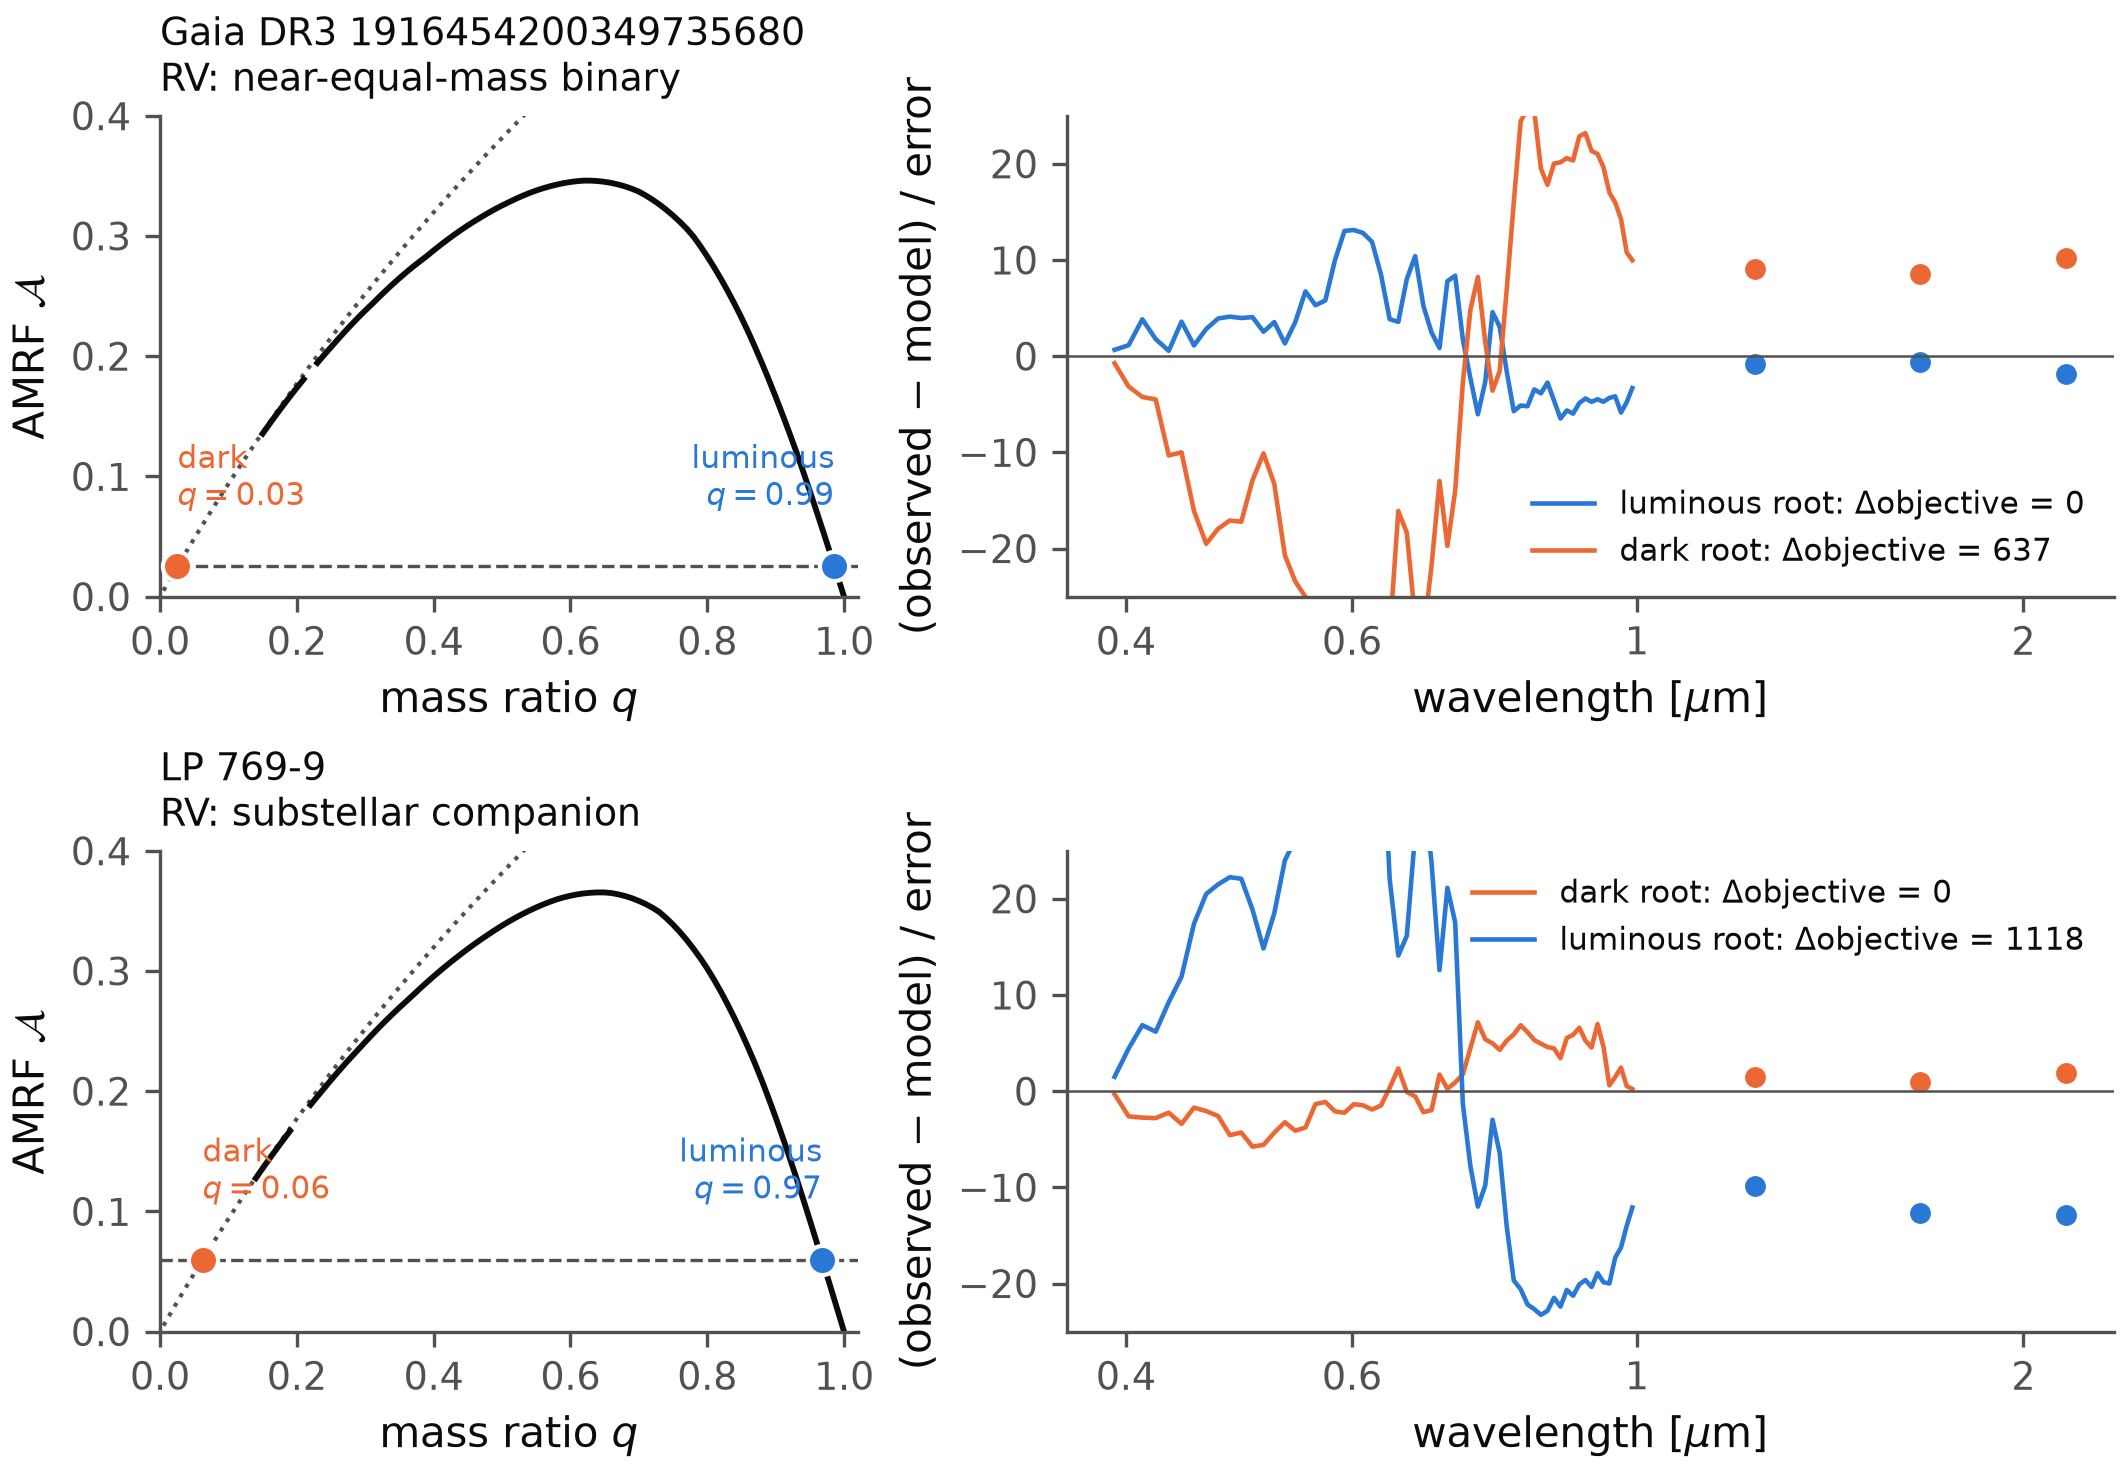

In [4]:
colour = {'dark': SINGLE, 'faint': SINGLE, 'luminous': BINARY}
wave = model.wavelength_um
order = np.argsort(wave[:61])
with plt.rc_context(PAPER_STYLE):
    fig, axes = plt.subplots(2, 2, figsize=(7.087, 4.9), layout='constrained',
                             gridspec_kw={'width_ratios': [1, 1.5]})
    for row, (sid, name, truth, a0, plx, period, m1) in zip(axes, SYSTEMS):
        a_obs = amrf_observed(a0, plx, period, m1)
        beta_g, _ = locus(m1, model=model)
        q = np.linspace(.005, 1, 200)
        ax = row[0]
        ax.plot(q, amrf(q, 0.), color=INK2, ls=':', lw=1, label='dark companion')
        ax.plot(Q_GRID, amrf(Q_GRID, beta_g), color=INK, lw=1.4, label='main-sequence companion')
        ax.axhline(a_obs, color=INK2, ls='--', lw=.8)
        for r in roots[sid]:
            ax.plot(r['q'], a_obs, 'o', ms=7, color=colour[r['kind']], mec='white', zorder=5)
            ax.annotate(f"{r['kind']}\n$q={r['q']:.2f}$", (r['q'], a_obs), xytext=(0, 12),
                        textcoords='offset points', fontsize=7.5, va='bottom',
                        ha='left' if r['q'] < .5 else 'right', color=colour[r['kind']])
        ax.set(xlim=(0, 1.02), ylim=(0, .4), xlabel='mass ratio $q$', ylabel=r'AMRF $\mathcal{A}$')
        ax.set_title(f'{name}\n{truth}', loc='left', fontsize=9)
        ax = row[1]
        sed = ranked[sid][0]
        for r in ranked[sid][1]:
            fit = r['fit']
            res = np.where(fit['mask'], (sed.flux - fit['flux']) / sed.error, np.nan)
            ax.plot(wave[:61][order], res[:61][order], color=colour[r['kind']], lw=1.1,
                    label=f"{r['kind']} root: $\\Delta$objective = {r['delta']:.0f}")
            ax.plot(wave[61:64], res[61:64], 'o', ms=4, color=colour[r['kind']])
        ax.axhline(0, color=INK2, lw=.6)
        ax.set_xscale('log')
        ax.set_xticks([.4, .6, 1, 2], ['0.4', '0.6', '1', '2'])
        ax.minorticks_off()
        ax.set(xlabel=r'wavelength [$\mu$m]', ylabel='(observed $-$ model) / error', ylim=(-25, 25))
        ax.legend(loc='best', fontsize=7.5)
    fig.savefig(OUT / '04_orbit_roots.png')
    fig.savefig(OUT / '04_orbit_roots.pdf')
plt.close(fig)
display(Image(filename=str(OUT / '04_orbit_roots.png')))

Left: $\mathcal{A}(q)$ for a dark (dotted) and a coeval main-sequence companion (solid),
the observed value (dashed) and its two solutions. Right: SED residuals at each solution.

## What this example tells us
From XP and 2MASS alone, the SED picks the luminous solution for the system that RVs
show is a near-equal-mass binary, and the dark solution for LP 769-9. The colour-magnitude
diagram agrees: the binary lies 0.68 mag above the single-star sequence in $K_s$, close to
the predicted 0.72 mag; LP 769-9 lies 0.15 mag above it.

Two systems are a demonstration, not a contamination rate. The companion model is a coeval
main-sequence star: white dwarfs and triples are not modelled, and extinction is zero.

**Discussion:** how many DR3/DR4 astrometric brown-dwarf candidates have a luminous
solution that their SED prefers?

**Try after the talk:** `python -m sedkit.orbit --a0 0.6978 --parallax 13.913 --period 339.57 --m1 0.686`
gives both solutions from the command line, without a spectrum.

Method and scope: [photocentre orbits](../../docs/orbit.md).
Previous: [observed SB2](01_observed_sb2.ipynb).

Figure-generating code: [04_gaia_orbit_twin.py](04_gaia_orbit_twin.py).